# mbox 키워드 메일 필터링 및 계정 상태 분석

이 노트북은 `mbox` 메일 백업 파일에서 보안 관련 메일을 골라낸 뒤, 전처리·임베딩·비지도학습을 거쳐 **발신자별 계정 상태를 탐색적으로 요약**합니다.

## 실행 순서
1. **키워드 메일 추출**: `mbox` 파일에서 `keywords`에 맞는 메일만 선택
2. **텍스트 전처리**: HTML/푸터 노이즈 제거 및 토큰화
3. **TF-IDF 임베딩**: 메일/발신자 단위 숫자 벡터 생성
4. **비지도 분석**: 군집화, 토픽 추출, 이상치 탐지
5. **자동 리포트**: 근거가 가장 많은 발신자 1명에 대한 요약 보고서 생성

> 위에서 아래로 순서대로 실행하면 됩니다. 현재 키워드는 `keywords = ["보안"]` 으로 설정되어 있으며, 필요하면 `로그인`, `계정`, `조치` 등을 함께 넣어 확장할 수 있습니다.

In [1]:
import mailbox
import re
import html
from html.parser import HTMLParser
from email.header import decode_header
from email.utils import parseaddr
from pathlib import Path

# 분석할 mbox 파일 경로
mbox_path = Path(r"c:/Users/hunji/Downloads/Takeout/메일/스팸함 및 휴지통을 포함한 모든 메일.mbox")

# 찾을 키워드
keywords = ["보안"]

def decode_mime_words(value):
    if not value:
        return ""

    decoded = []
    for part, enc in decode_header(value):
        if isinstance(part, bytes):
            for candidate in [enc, "utf-8", "cp949", "euc-kr", "latin1"]:
                if not candidate:
                    continue
                try:
                    decoded.append(part.decode(candidate, errors="replace"))
                    break
                except Exception:
                    continue
            else:
                decoded.append(part.decode("utf-8", errors="replace"))
        else:
            decoded.append(part)
    return "".join(decoded)

class VisibleTextParser(HTMLParser):
    skip_tags = {"script", "style", "head", "title", "meta", "noscript"}

    def __init__(self):
        super().__init__()
        self._skip_depth = 0
        self._parts = []

    def handle_starttag(self, tag, attrs):
        if tag.lower() in self.skip_tags:
            self._skip_depth += 1

    def handle_endtag(self, tag):
        if tag.lower() in self.skip_tags and self._skip_depth > 0:
            self._skip_depth -= 1

    def handle_data(self, data):
        if self._skip_depth == 0 and data and data.strip():
            self._parts.append(data.strip())

    def get_text(self):
        return " ".join(self._parts)

def html_to_visible_text(raw_html):
    raw_html = raw_html[:300000]
    raw_html = re.sub(r"<!--.*?-->", " ", raw_html, flags=re.S)

    parser = VisibleTextParser()
    parser.feed(raw_html)
    parser.close()

    text = html.unescape(parser.get_text())
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[\w\.-]+@[\w\.-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_text_body(msg):
    chunks = []
    parts = msg.walk() if msg.is_multipart() else [msg]

    for part in parts:
        content_type = part.get_content_type()
        disposition = str(part.get("Content-Disposition", ""))

        if "attachment" in disposition.lower():
            continue
        if content_type not in ["text/plain", "text/html"]:
            continue

        payload = part.get_payload(decode=True)
        if not payload:
            continue

        charset = part.get_content_charset() or "utf-8"
        try:
            text = payload.decode(charset, errors="replace")
        except Exception:
            text = payload.decode("utf-8", errors="replace")

        if content_type == "text/html":
            text = html_to_visible_text(text)
        else:
            text = html.unescape(text)
            text = re.sub(r"\s+", " ", text).strip()

        if text:
            chunks.append(text[:5000])

    return "\n".join(chunks)

matched = []
mbox = mailbox.mbox(str(mbox_path))

for i, msg in enumerate(mbox):
    subject = decode_mime_words(msg.get("Subject", ""))
    sender_raw = decode_mime_words(msg.get("From", ""))
    sender_name, sender_email = parseaddr(sender_raw)
    sender_email = sender_email.lower().strip()
    sender_domain = sender_email.split("@")[-1] if "@" in sender_email else ""
    sender = f"{sender_name} <{sender_email}>" if sender_email else sender_raw
    date = decode_mime_words(msg.get("Date", ""))
    body = extract_text_body(msg)

    searchable = f"{subject}\n{body}"
    found_keywords = [kw for kw in keywords if kw in searchable]

    if found_keywords:
        matched.append({
            "index": i,
            "sender": sender,
            "sender_email": sender_email,
            "sender_domain": sender_domain,
            "subject": subject,
            "date": date,
            "body": body,
            "matched_keywords": ", ".join(found_keywords),
        })

print(f"총 {len(matched)}개의 메일이 키워드와 일치했습니다.")

if not matched:
    print("일치하는 메일이 없습니다.")
else:
    unique_senders = sorted({item['sender'] for item in matched if item['sender']})
    print("\n[발신자 목록 - 중복 제거]")
    for sender in unique_senders[:30]:
        print(sender)

    print("\n[일치한 메일 상위 10건]")
    for item in matched[:10]:
        print(f"- 발신자: {item['sender']}")
        print(f"  제목: {item['subject']}")
        print(f"  날짜: {item['date']}")
        print(f"  키워드: {item['matched_keywords']}\n")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\hunji\\Downloads\\Takeout\\메일\\스팸함 및 휴지통을 포함한 모든 메일.mbox'

## 2단계: 전처리와 TF-IDF 임베딩 준비

다음 두 코드 셀은 **모델이 읽기 좋은 형태로 메일 텍스트를 정리하는 과정**입니다.

### 먼저 수행하는 일
- 메일 본문을 소문자 기준으로 정규화
- URL, 이메일 주소, HTML/CSS 잔여물 제거
- 한국어/영문 토큰만 남기고 불용어 제거
- 발신자별 대표 단어와 메일 수 집계

### 이어서 수행하는 일
- 정제된 토큰을 `TF-IDF` 벡터로 변환
- **메일 단위 벡터**와 **발신자 단위 벡터**를 각각 생성

### 핵심 결과 변수
- `preprocessed_records`: 메일별 정제 결과
- `sender_profiles`: 발신자별 대표 키워드
- `mail_tfidf_matrix`, `sender_tfidf_matrix`: 분석용 숫자 벡터

In [13]:
import re
import html
from collections import Counter, defaultdict

if "matched" not in globals():
    raise ValueError("먼저 키워드 메일 추출 셀을 실행해 matched 데이터를 생성하세요.")
if not matched:
    raise ValueError("키워드에 일치하는 메일이 없습니다.")

# 비지도학습 전처리용 불용어
stopwords = {
    "안녕하세요", "고객님", "감사합니다", "문의", "확인", "이용", "관련", "안내", "서비스",
    "회원", "정보", "부탁드립니다", "바랍니다", "드립니다", "입니다", "되었습니다", "가능합니다",
    "the", "and", "for", "from", "that", "this", "with", "your", "you", "have", "has",
    "will", "was", "are", "not", "please", "mail", "email", "account", "login",
    "px", "font", "display", "width", "margin", "color", "background", "class", "important",
    "media", "block", "normal", "center", "left", "right", "all", "max", "min", "img", "src",
    "td", "tr", "th", "tbody", "thead", "table", "span", "div", "nbsp", "href", "http", "https",
    "roboto", "arial", "sans", "serif", "padding", "border", "radius", "height", "family", "align",
    "mso", "woff", "woff2", "format", "local", "top", "bottom", "row", "col", "ib", "mb", "flex"
}

def preprocess_text(text):
    text = (text or "").lower()
    text = html.unescape(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[\w\.-]+@[\w\.-]+", " ", text)
    text = re.sub(r"[^0-9a-zA-Z가-힣\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = re.findall(r"[가-힣]{2,}|[a-z]{2,}|\d{2,}", text)
    tokens = [
        token for token in tokens
        if token not in stopwords
        and len(token) > 1
        and not re.fullmatch(r"\d+(px|pt|em|rem)", token)
    ]
    return text, tokens

preprocessed_records = []
sender_mail_counts = Counter()
sender_token_bags = defaultdict(list)

for item in matched:
    combined_text = f"{item['subject']}\n{item['body']}"
    clean_text, tokens = preprocess_text(combined_text)

    sender_key = item.get("sender_email") or item.get("sender") or "unknown_sender"
    sender_mail_counts[sender_key] += 1
    sender_token_bags[sender_key].extend(tokens)

    preprocessed_records.append({
        **item,
        "clean_text": clean_text,
        "tokens": tokens,
        "token_count": len(tokens),
    })

sender_profiles = {
    sender: Counter(tokens).most_common(15)
    for sender, tokens in sender_token_bags.items()
}

print(f"전처리 완료: {len(preprocessed_records)}건")
print(f"발신자 수: {len(sender_profiles)}명")

print("\n[전처리 예시 3건]")
for row in preprocessed_records[:3]:
    print(f"- 발신자: {row['sender']}")
    print(f"  제목: {row['subject']}")
    print(f"  정제 본문 미리보기: {row['clean_text'][:120]}...")
    print(f"  토큰 상위 15개: {row['tokens'][:15]}\n")

print("[발신자별 메일 수 상위 10명]")
for sender, count in sender_mail_counts.most_common(10):
    print(f"- {sender}: {count}건")

print("\n[발신자별 대표 키워드 예시]")
for sender, token_stats in list(sender_profiles.items())[:5]:
    top_terms = ", ".join([f"{token}({freq})" for token, freq in token_stats[:10]])
    print(f"- {sender}: {top_terms}")

# 다음 단계에서 바로 사용 가능한 변수
# - preprocessed_records: 메일 단위 전처리 결과
# - sender_profiles: 발신자별 상위 토큰
# - sender_mail_counts: 발신자별 메일 개수

전처리 완료: 239건
발신자 수: 29명

[전처리 예시 3건]
- 발신자:  <password-reset-no-reply@verify.signin.aws>
  제목: Amazon Web Services 비밀번호 지원
  정제 본문 미리보기: amazon web services 비밀번호 지원 amazon web services에서 알려 드립니다 이 이메일 주소와 연결된 aws 계정의 비밀번호 재설정 요청을 받았습니다 아래 링크를 클릭한 후 보안 서버를 사...
  토큰 상위 15개: ['amazon', 'web', 'services', '비밀번호', '지원', 'amazon', 'web', 'services', '에서', '알려', '이메일', '주소와', '연결된', 'aws', '계정의']

- 발신자: X <verify@x.com>
  제목: Windows의 ChromeDesktop에서 X에 새로 로그인했습니다
  정제 본문 미리보기: windows의 chromedesktop에서 x에 새로 로그인했습니다 x 새로운 디바이스에서 vailzest 계정에 로그인되었습니다 본인이 로그인하셨나요 새로운 로그인 위치 대한민국 종로구 대한민국 위치는 로그인 i...
  토큰 상위 15개: ['windows', 'chromedesktop', '에서', '새로', '로그인했습니다', '새로운', '디바이스에서', 'vailzest', '계정에', '로그인되었습니다', '본인이', '로그인하셨나요', '새로운', '로그인', '위치']

- 발신자: Google <no-reply@accounts.google.com>
  제목: 보안 알림
  정제 본문 미리보기: 보안 알림 image google 일부 google 계정 데이터에 대한 smore의 액세스를 허용하셨습니다 일부 google 계정 데이터에 대한 smore의 액세스를 허용하지 않으셨다면 다른 사람이 내 google ...
  토큰 상위 15개: ['보안', '알림', 'image', 'google', '일부', 

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

if "preprocessed_records" not in globals() or not preprocessed_records:
    raise ValueError("먼저 전처리 셀을 실행해 preprocessed_records를 생성하세요.")

# 메일 단위 문서 생성
mail_documents = [
    " ".join(row["tokens"]) if row["tokens"] else row["clean_text"]
    for row in preprocessed_records
]

mail_vectorizer = TfidfVectorizer(
    max_features=2000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2)
)
mail_tfidf_matrix = mail_vectorizer.fit_transform(mail_documents)
mail_feature_names = mail_vectorizer.get_feature_names_out()

print(f"메일 단위 TF-IDF 행렬 크기: {mail_tfidf_matrix.shape}")

print("\n[메일별 TF-IDF 대표 키워드 예시 5건]")
for idx, row in enumerate(preprocessed_records[:5]):
    scores = mail_tfidf_matrix[idx].toarray().ravel()
    top_indices = scores.argsort()[-10:][::-1]
    top_terms = [(mail_feature_names[i], round(float(scores[i]), 3)) for i in top_indices if scores[i] > 0]

    print(f"- 발신자: {row['sender']}")
    print(f"  제목: {row['subject']}")
    print(f"  대표 키워드: {top_terms}\n")

# 발신자 단위 문서 생성
sender_documents = {}
for row in preprocessed_records:
    sender_key = row.get("sender_email") or row.get("sender") or "unknown_sender"
    sender_documents.setdefault(sender_key, [])
    sender_documents[sender_key].append(" ".join(row["tokens"]))

sender_ids = list(sender_documents.keys())
sender_corpus = [" ".join(sender_documents[sender]) for sender in sender_ids]

sender_vectorizer = TfidfVectorizer(
    max_features=1500,
    min_df=1,
    max_df=0.9,
    ngram_range=(1, 2)
)
sender_tfidf_matrix = sender_vectorizer.fit_transform(sender_corpus)
sender_feature_names = sender_vectorizer.get_feature_names_out()

print(f"발신자 단위 TF-IDF 행렬 크기: {sender_tfidf_matrix.shape}")

print("\n[발신자별 대표 키워드 예시 5명]")
for row_idx, sender in enumerate(sender_ids[:5]):
    scores = sender_tfidf_matrix[row_idx].toarray().ravel()
    top_indices = scores.argsort()[-10:][::-1]
    top_terms = [(sender_feature_names[i], round(float(scores[i]), 3)) for i in top_indices if scores[i] > 0]
    print(f"- {sender}: {top_terms}")

# 다음 단계에서 바로 사용 가능한 변수
# - mail_tfidf_matrix: 메일 단위 TF-IDF 벡터
# - sender_tfidf_matrix: 발신자 단위 TF-IDF 벡터
# - sender_ids: 발신자 목록

메일 단위 TF-IDF 행렬 크기: (239, 2000)

[메일별 TF-IDF 대표 키워드 예시 5건]
- 발신자:  <password-reset-no-reply@verify.signin.aws>
  제목: Amazon Web Services 비밀번호 지원
  대표 키워드: [('web', 0.514), ('amazon', 0.487), ('services', 0.399), ('링크를', 0.279), ('비밀번호', 0.18), ('경우', 0.163), ('이메일을', 0.16), ('재설정 요청을', 0.139), ('요청을', 0.139), ('재설정', 0.105)]

- 발신자: X <verify@x.com>
  제목: Windows의 ChromeDesktop에서 X에 새로 로그인했습니다
  대표 키워드: [('vailzest', 0.259), ('대한민국', 0.23), ('새로운', 0.224), ('로그인', 0.222), ('본인이', 0.218), ('경우', 0.191), ('별도로', 0.163), ('본인이 아닌', 0.163), ('디바이스에서', 0.156), ('활성', 0.156)]

- 발신자: Google <no-reply@accounts.google.com>
  제목: 보안 알림
  대표 키워드: [('계정 데이터에', 0.312), ('데이터에', 0.284), ('google', 0.209), ('일부 google', 0.208), ('데이터에 대한', 0.203), ('일부', 0.185), ('액세스를', 0.178), ('google 계정', 0.167), ('대한', 0.14), ('데이터에 액세스하려는', 0.104)]

- 발신자: Google <no-reply@accounts.google.com>
  제목: 보안 알림
  대표 키워드: [('app', 0.357), ('계정 데이터에', 0.292), ('데이터에', 0.265), ('google', 0.196), ('일부 google', 0.194), (

## 3단계: 비지도 분석

이 구간에서는 정제된 TF-IDF 벡터를 사용해 **비슷한 성격의 메일끼리 묶고**, **숨은 주제**와 **이상 패턴**을 찾습니다.

### 포함된 분석
- **`KMeans`**: 전체 메일을 몇 개의 대표 군집으로 나누는 기본 군집화
- **`HDBSCAN`**: 밀도가 높은 그룹을 자동으로 찾아주며, 애매한 메일은 `노이즈(-1)`로 분리
- **`BERTopic`**: 군집과 단어 패턴을 이용해 토픽 이름과 대표 단어 추출
- **`Isolation Forest`**: 다른 발신자와 패턴이 유난히 다른 계정을 이상치로 탐지

### 그래프 해석 팁
- 산점도에서 **가까이 모인 점**은 내용이 유사한 메일입니다.
- `HDBSCAN`에서 `-1`은 특정 그룹에 속하지 않는 **예외적 메일**을 뜻합니다.
- 토픽 막대그래프는 **어떤 유형의 메일이 많이 등장하는지** 보여줍니다.
- 이상치 점수가 높을수록 **다른 발신자와 패턴이 더 다르다**는 뜻입니다.

KMeans 군집 수: 3
HDBSCAN 군집 수(노이즈 제외): 3
HDBSCAN 노이즈 메일 수: 84

[KMeans 군집별 상위 키워드]
- Cluster 0: [('google', 0.193), ('변경하여 그동안', 0.149), ('못했다고', 0.149), ('의심된다면', 0.149), ('완료 계정을', 0.149), ('완료', 0.149), ('보안을 검토하고', 0.149), ('복구 완료', 0.149)]
- Cluster 1: [('google', 0.115), ('microsoft', 0.061), ('보안', 0.046), ('google 계정', 0.042), ('있습니다', 0.038), ('microsoft 계정', 0.037), ('로그인', 0.036), ('위해', 0.034)]
- Cluster 2: [('새로', 0.19), ('google', 0.189), ('취하지 않아도', 0.113), ('않아도', 0.113), ('안내에', 0.113), ('조치를 취하지', 0.113), ('따라 계정을', 0.113), ('안내에 따라', 0.113)]


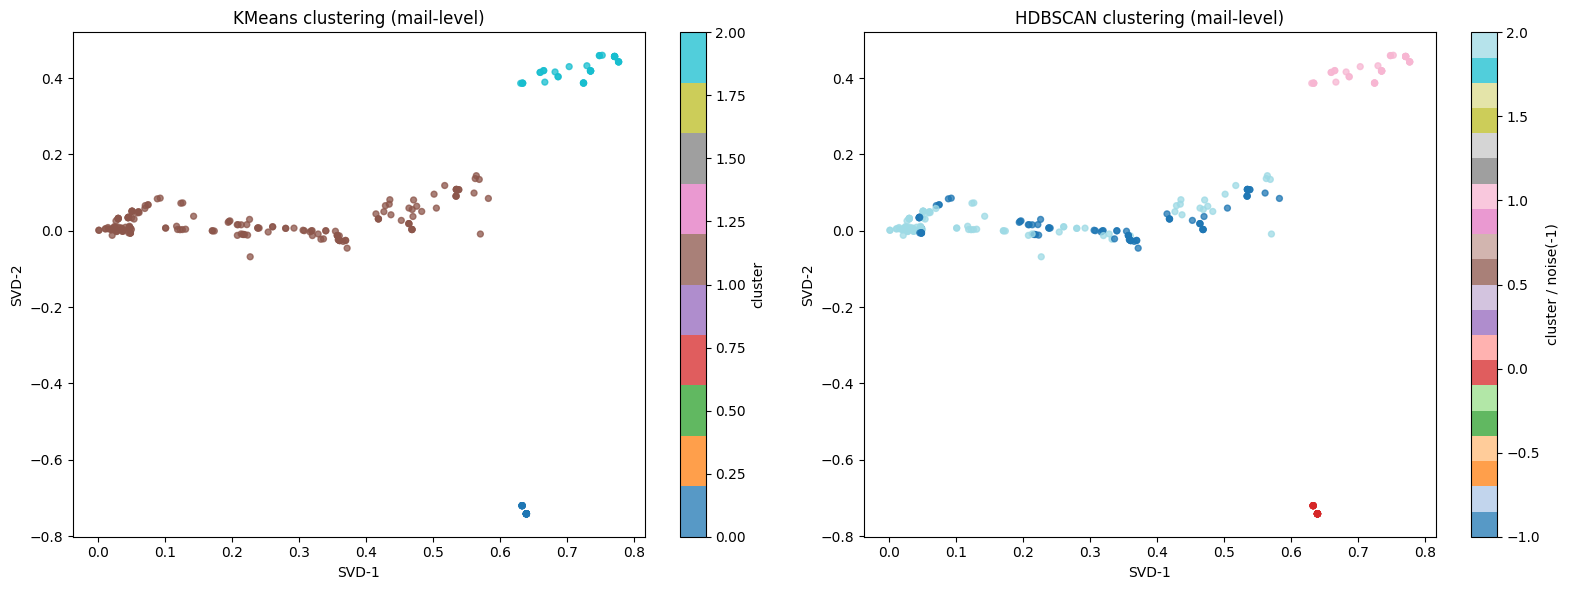


[KMeans 군집별 예시 메일 2건]

Cluster 0
- Google <no-reply@accounts.google.com> | Google 계정 복구가 완료되었습니다 | 보안
- Google <no-reply@accounts.google.com> | Google 계정 복구가 완료되었습니다 | 보안

Cluster 1
-  <password-reset-no-reply@verify.signin.aws> | Amazon Web Services 비밀번호 지원 | 보안
- X <verify@x.com> | Windows의 ChromeDesktop에서 X에 새로 로그인했습니다 | 보안

Cluster 2
- Google <no-reply@accounts.google.com> | 보안 알림 | 보안
- Google <no-reply@accounts.google.com> | 보안 알림 | 보안


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import hdbscan

if "mail_tfidf_matrix" not in globals() or "preprocessed_records" not in globals():
    raise ValueError("먼저 1~3번 셀을 실행해 TF-IDF 데이터를 준비하세요.")

mail_docs_count = len(preprocessed_records)
if mail_docs_count < 10:
    raise ValueError("군집화를 진행하기에 메일 수가 너무 적습니다.")

# 시각화를 위한 차원 축소
n_components = min(20, max(2, mail_tfidf_matrix.shape[1] - 1))
svd_for_cluster = TruncatedSVD(n_components=n_components, random_state=42)
mail_reduced = svd_for_cluster.fit_transform(mail_tfidf_matrix)
mail_2d = mail_reduced[:, :2]

# KMeans 군집화
n_clusters = min(6, max(3, mail_docs_count // 700 + 3))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(mail_reduced)

# HDBSCAN 군집화
hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5, metric="euclidean")
hdbscan_labels = hdb.fit_predict(mail_reduced)

cluster_results_df = pd.DataFrame({
    "sender": [row["sender"] for row in preprocessed_records],
    "subject": [row["subject"] for row in preprocessed_records],
    "matched_keywords": [row["matched_keywords"] for row in preprocessed_records],
    "kmeans_cluster": kmeans_labels,
    "hdbscan_cluster": hdbscan_labels,
    "x": mail_2d[:, 0],
    "y": mail_2d[:, 1],
})

print(f"KMeans 군집 수: {len(set(kmeans_labels))}")
print(f"HDBSCAN 군집 수(노이즈 제외): {len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)}")
print(f"HDBSCAN 노이즈 메일 수: {(hdbscan_labels == -1).sum()}")

print("\n[KMeans 군집별 상위 키워드]")
for cluster_id in sorted(cluster_results_df['kmeans_cluster'].unique()):
    cluster_mask = (cluster_results_df['kmeans_cluster'] == cluster_id).to_numpy()
    cluster_mean = np.asarray(mail_tfidf_matrix[cluster_mask].mean(axis=0)).ravel()
    top_indices = cluster_mean.argsort()[-8:][::-1]
    top_terms = [(mail_feature_names[i], round(float(cluster_mean[i]), 3)) for i in top_indices if cluster_mean[i] > 0]
    print(f"- Cluster {cluster_id}: {top_terms}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    cluster_results_df['x'], cluster_results_df['y'],
    c=cluster_results_df['kmeans_cluster'], cmap='tab10', s=18, alpha=0.75
)
axes[0].set_title('KMeans clustering (mail-level)')
axes[0].set_xlabel('SVD-1')
axes[0].set_ylabel('SVD-2')
fig.colorbar(scatter1, ax=axes[0], label='cluster')

scatter2 = axes[1].scatter(
    cluster_results_df['x'], cluster_results_df['y'],
    c=cluster_results_df['hdbscan_cluster'], cmap='tab20', s=18, alpha=0.75
)
axes[1].set_title('HDBSCAN clustering (mail-level)')
axes[1].set_xlabel('SVD-1')
axes[1].set_ylabel('SVD-2')
fig.colorbar(scatter2, ax=axes[1], label='cluster / noise(-1)')

plt.tight_layout()
plt.show()

print("\n[KMeans 군집별 예시 메일 2건]")
for cluster_id in sorted(cluster_results_df['kmeans_cluster'].unique()):
    sample_rows = cluster_results_df[cluster_results_df['kmeans_cluster'] == cluster_id].head(2)
    print(f"\nCluster {cluster_id}")
    for _, sample in sample_rows.iterrows():
        print(f"- {sample['sender']} | {sample['subject']} | {sample['matched_keywords']}")

# 다음 단계에서 재사용
# - cluster_results_df
# - kmeans_labels
# - hdbscan_labels
# - mail_2d

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2201.78it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERTopic 상위 토픽]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,18,-1_mb_facebook_facebook facebook_text,"[mb, facebook, facebook facebook, text, work t...",[계정이 잠금 해제되었습니다 러스님 안녕하세요 러스님 안녕하세요 11월 25일 오전...
1,0,78,0_google_google google_none_text,"[google, google google, none, text, decoration...",[보안 알림 image google 일부 google 계정 데이터에 대한 spark...
2,1,55,1_text_mb_body_padding,"[text, mb, body, padding, none, microsoft, tex...",[보안 알림 image google 비밀번호가 변경되었습니다 내 google 계정 ...
3,2,37,2_windows_google_microsoft_size,"[windows, google, microsoft, size, cls, none, ...",[보안 알림 image google windows에서 새로 로그인함 windows ...
4,3,32,3_google_decoration none_decoration_text decor...,"[google, decoration none, decoration, text dec...",[보안 알림 image google 새로운 계정 로그인 내 google 계정에 새로...
5,4,29,4_decoration none_decoration_text decoration_g...,"[decoration none, decoration, text decoration,...",[google 계정 복구가 완료되었습니다 image google 계정 복구 완료 계...


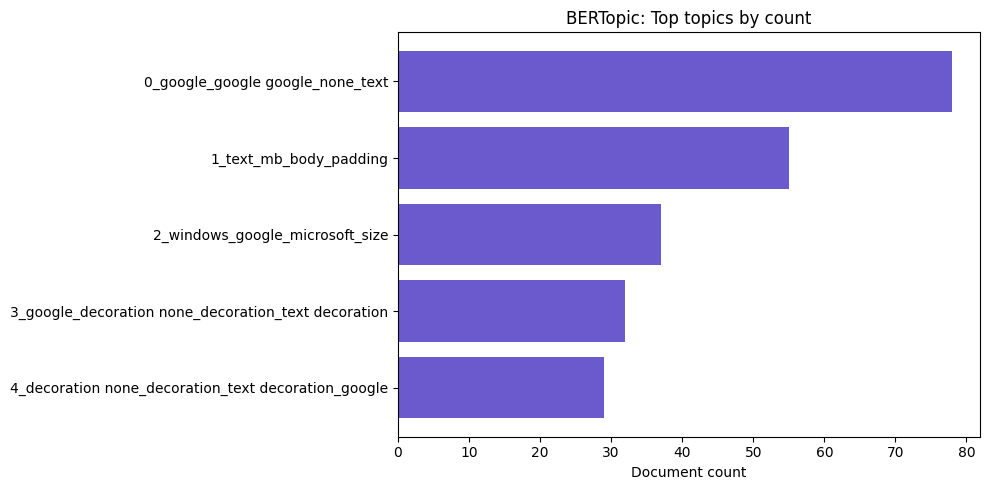


[Topic 0 대표 단어]
[('google', np.float64(0.1360036498553879)), ('google google', np.float64(0.11207106307903965)), ('none', np.float64(0.03972057527375842)), ('text', np.float64(0.03722708500772539)), ('decoration none', np.float64(0.037152267129179684)), ('decoration', np.float64(0.03702344534265266)), ('text decoration', np.float64(0.03702344534265266)), ('padding', np.float64(0.03504955188551917)), ('mountain view', np.float64(0.028236273609400973)), ('mountain', np.float64(0.028236273609400973))]

[Topic 1 대표 단어]
[('text', np.float64(0.06726843004883704)), ('mb', np.float64(0.04879961215171161)), ('body', np.float64(0.047737259584566163)), ('padding', np.float64(0.047209235568546004)), ('none', np.float64(0.046272089679999476)), ('microsoft', np.float64(0.04372054490601843)), ('text decoration', np.float64(0.03844284058605948)), ('decoration', np.float64(0.03844284058605948)), ('height', np.float64(0.038235478877111394)), ('decoration none', np.float64(0.0370437560316494))]

[Topic 

,sender_id,anomaly_flag,anomaly_score,mail_count
2,no-reply@accounts.google.com,-1,0.279610,155
13,security@facebookmail.com,-1,0.063345,10
5,account-security-noreply@accountprotection.mic...,-1,0.037039,29
23,google-noreply@google.com,1,-0.029102,4
30,msa@communication.microsoft.com,1,-0.047629,1
28,no-reply@riotgames.co.kr,1,-0.049395,3
7,mail@eg.hotels.com,1,-0.057018,2
18,no-reply@google.com,1,-0.061938,1
6,no-reply@mail.instagram.com,1,-0.065808,2
1,verify@x.com,1,-0.076745,2


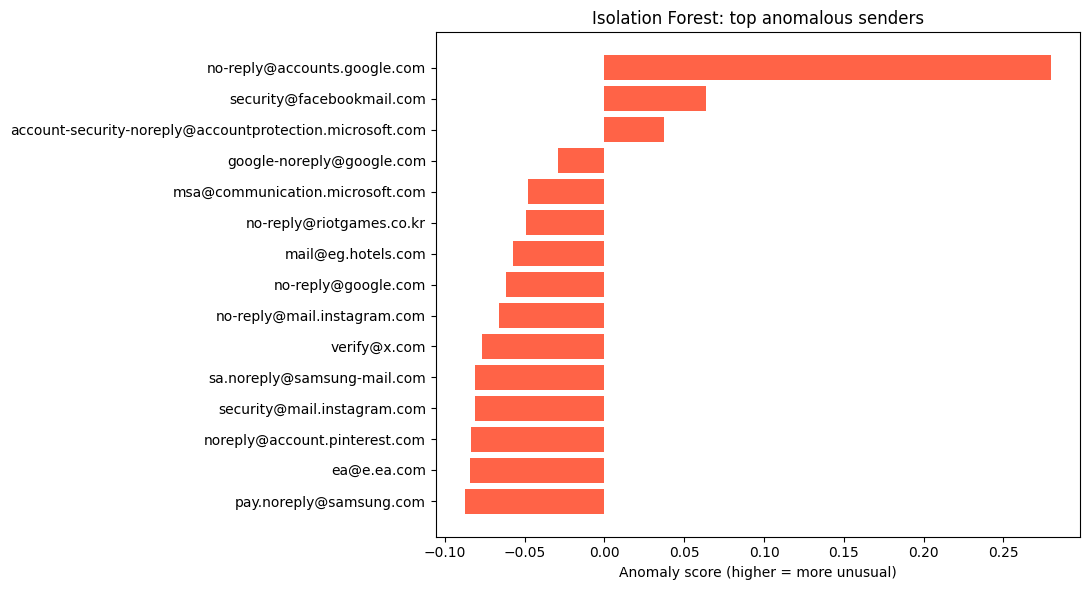


[해석 가이드]
- KMeans/HDBSCAN: 비슷한 성격의 메일 그룹 확인
- BERTopic: 자주 등장하는 숨은 주제 확인
- Isolation Forest: 다른 발신자와 패턴이 많이 다른 계정/발신자 탐지


In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

if "preprocessed_records" not in globals() or not preprocessed_records:
    raise ValueError("먼저 전처리 셀을 실행하세요.")
if "sender_tfidf_matrix" not in globals() or "sender_ids" not in globals():
    raise ValueError("먼저 TF-IDF 셀을 실행하세요.")

# BERTopic 토픽 추출
topic_docs = [row["clean_text"] if row["clean_text"] else " ".join(row["tokens"]) for row in preprocessed_records]
vectorizer_model = CountVectorizer(stop_words=list(stopwords), ngram_range=(1, 2), min_df=2)

topic_model = BERTopic(
    embedding_model=None,
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    calculate_probabilities=False,
    verbose=False
)

topics, _ = topic_model.fit_transform(topic_docs)
topic_info = topic_model.get_topic_info()

print("[BERTopic 상위 토픽]")
display(topic_info.head(10))

plot_topic_info = topic_info[topic_info['Topic'] != -1].head(10).copy()
plt.figure(figsize=(10, 5))
plt.barh(plot_topic_info['Name'][::-1], plot_topic_info['Count'][::-1], color='slateblue')
plt.title('BERTopic: Top topics by count')
plt.xlabel('Document count')
plt.tight_layout()
plt.show()

for topic_id in plot_topic_info['Topic'].head(5):
    print(f"\n[Topic {topic_id} 대표 단어]")
    print(topic_model.get_topic(topic_id)[:10])

# Isolation Forest 이상치 탐지 (발신자 단위)
sender_dense = sender_tfidf_matrix.toarray()
iso_forest = IsolationForest(contamination=0.08, random_state=42)
iso_pred = iso_forest.fit_predict(sender_dense)
anomaly_score = -iso_forest.decision_function(sender_dense)

sender_anomaly_df = pd.DataFrame({
    'sender_id': sender_ids,
    'anomaly_flag': iso_pred,
    'anomaly_score': anomaly_score,
    'mail_count': [sender_mail_counts.get(sender, 0) for sender in sender_ids]
}).sort_values('anomaly_score', ascending=False)

print("\n[이상치 발신자 상위 15명]")
display(sender_anomaly_df.head(15))

plt.figure(figsize=(11, 6))
plot_df = sender_anomaly_df.head(15).sort_values('anomaly_score', ascending=True)
plt.barh(plot_df['sender_id'], plot_df['anomaly_score'], color='tomato')
plt.title('Isolation Forest: top anomalous senders')
plt.xlabel('Anomaly score (higher = more unusual)')
plt.tight_layout()
plt.show()

print("\n[해석 가이드]")
print("- KMeans/HDBSCAN: 비슷한 성격의 메일 그룹 확인")
print("- BERTopic: 자주 등장하는 숨은 주제 확인")
print("- Isolation Forest: 다른 발신자와 패턴이 많이 다른 계정/발신자 탐지")

# 다음 단계에서 재사용
# - topic_model, topic_info
# - sender_anomaly_df

## 4단계: 발신자별 계정 상태 추정

이 단계에서는 앞에서 만든 비지도 분석 결과와 보안 신호 키워드를 합쳐 **발신자 단위 요약표**를 만듭니다.

### 어떻게 계산하나?
- `reset_signal`: 비밀번호 재설정/복구 관련 표현 빈도
- `login_signal`: 로그인/인증/코드 관련 표현 빈도
- `alert_signal`: 보안 알림, 경고, 위험, 차단 관련 표현 빈도
- `action_signal`: 조치, 권장, 확인, 변경 같은 후속 액션 표현 빈도
- `anomaly_score`: 발신자 패턴이 다른 계정과 얼마나 다른지 나타내는 점수

이 값을 조합해 `risk_score`, `risk_level`, `account_state`를 만들며, 결과는 **탐색용 휴리스틱**입니다.

> 즉, 실제 침해 여부를 확정하는 진단이 아니라 **우선 확인이 필요한 발신자를 빠르게 좁히기 위한 요약**으로 보면 됩니다.

[발신자별 계정 상태 추정 상위 15명]


,sender_name,mail_count,risk_level,account_state,risk_score,anomaly_score,dominant_cluster,dominant_topic_name,sample_subject
0,<google-cloud-compliance@google.com>,2,높음,로그인 이상 탐지,96.779831,-0.102521,1,unknown,midyear-system-322103에 대한 즉각적인 조치 필요
1,Google Cloud <cloudplatform-noreply@google.com>,1,높음,로그인 이상 탐지,81.292191,-0.088476,1,unknown,[조치 권장] Google Cloud 사용자 인증 정보 보안 권장사항 검토 \n\n
2,Facebook <security@facebookmail.com>,10,높음,복구/비밀번호 재설정,63.996759,0.063345,1,unknown,09711806은(는) 회원님의 비밀번호 재설정 코드입니다
3,삼성계정 <sa.noreply@samsung-mail.com>,2,높음,복구/비밀번호 재설정,42.050447,-0.081194,1,unknown,삼성계정에 새로 로그인
4,Samsung Pay <pay.noreply@samsung.com>,2,높음,복구/비밀번호 재설정,39.101770,-0.087279,1,unknown,삼성페이 개인정보 이용내역 안내
5,X <verify@x.com>,2,높음,복구/비밀번호 재설정,36.586040,-0.076745,1,unknown,Windows의 ChromeDesktop에서 X에 새로 로그인했습니다
6,<googlekrsupport@google.com>,1,높음,복구/비밀번호 재설정,34.453414,-0.118323,1,unknown,Re: Google에 문의해 주셔서 감사합니다 [4-6928000032984]
7,Google <no-reply@accounts.google.com>,155,높음,복구/비밀번호 재설정,34.169136,0.279610,1,unknown,보안 알림
8,Microsoft <msa@communication.microsoft.com>,1,높음,복구/비밀번호 재설정,29.818965,-0.047629,1,unknown,개인정보 이용내역 통지 안내 | Notice on the use of persona...
9,Microsoft 계정 팀 <account-security-noreply@accou...,29,높음,복구/비밀번호 재설정,28.944585,0.037039,1,unknown,Microsoft 계정 암호 변경


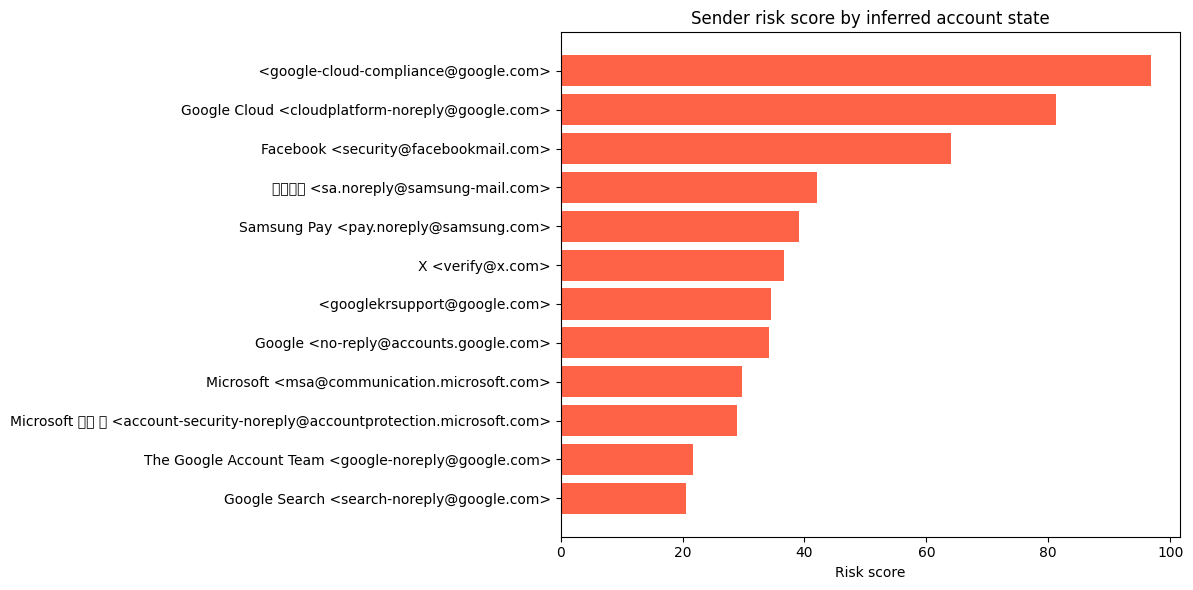

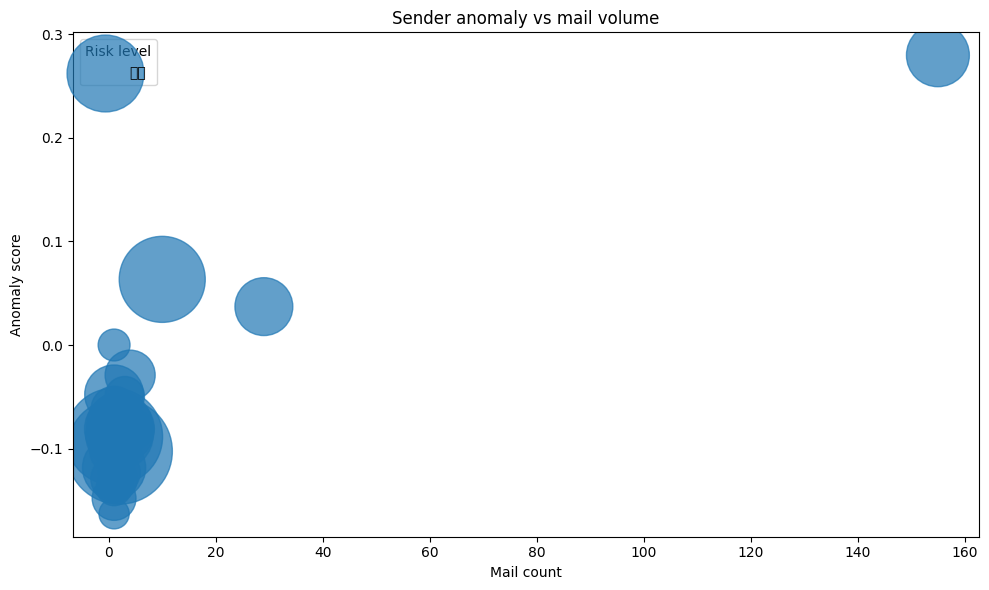


[상태별 발신자 수]
account_state
로그인 이상 탐지      10
복구/비밀번호 재설정    10
보안 조치 필요        9
Name: count, dtype: int64


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "preprocessed_records" not in globals() or "sender_anomaly_df" not in globals():
    raise ValueError("먼저 앞의 셀들을 순서대로 실행해 분석 결과를 준비하세요.")

sender_analysis_df = pd.DataFrame(preprocessed_records).copy()
sender_analysis_df["sender_key"] = sender_analysis_df["sender_email"].fillna("")
sender_analysis_df["sender_key"] = sender_analysis_df["sender_key"].where(
    sender_analysis_df["sender_key"] != "",
    sender_analysis_df["sender"]
)

signal_terms = {
    "reset_signal": ["비밀번호", "재설정", "reset", "recover", "recovery", "복구", "password"],
    "login_signal": ["로그인", "signin", "sign in", "인증", "코드", "otp", "verify", "verification", "로그인되었습니다", "새로 로그인"],
    "alert_signal": ["보안", "security", "알림", "경고", "의심", "위험", "suspicious", "차단", "잠금", "잠김", "보호"],
    "action_signal": ["조치", "권장", "확인", "검토", "review", "변경", "update", "필수", "승인", "해제"]
}

def count_signal_hits(text, terms):
    text = (text or "").lower()
    return sum(text.count(term.lower()) for term in terms)

for col_name, terms in signal_terms.items():
    sender_analysis_df[col_name] = sender_analysis_df["clean_text"].apply(lambda x: count_signal_hits(x, terms))

if "kmeans_labels" in globals() and len(kmeans_labels) == len(sender_analysis_df):
    sender_analysis_df["kmeans_cluster"] = kmeans_labels
else:
    sender_analysis_df["kmeans_cluster"] = -1

if "topics" in globals() and len(topics) == len(sender_analysis_df):
    sender_analysis_df["topic_id"] = topics
else:
    sender_analysis_df["topic_id"] = -999

topic_name_map = {}
if "topic_info" in globals() and isinstance(topic_info, pd.DataFrame):
    topic_name_map = dict(zip(topic_info["Topic"], topic_info["Name"]))

def most_common_value(series):
    series = pd.Series(series)
    if series.empty:
        return None
    return series.value_counts().idxmax()

sender_status_df = sender_analysis_df.groupby("sender_key").agg(
    sender_name=("sender", "first"),
    mail_count=("sender_key", "size"),
    sample_subject=("subject", "first"),
    reset_signal=("reset_signal", "sum"),
    login_signal=("login_signal", "sum"),
    alert_signal=("alert_signal", "sum"),
    action_signal=("action_signal", "sum"),
    dominant_cluster=("kmeans_cluster", most_common_value),
    dominant_topic=("topic_id", most_common_value),
).reset_index()

sender_status_df = sender_status_df.merge(
    sender_anomaly_df[["sender_id", "anomaly_flag", "anomaly_score"]],
    left_on="sender_key",
    right_on="sender_id",
    how="left"
).drop(columns=["sender_id"])

sender_status_df["anomaly_score"] = sender_status_df["anomaly_score"].fillna(0.0)
sender_status_df["anomaly_flag"] = sender_status_df["anomaly_flag"].fillna(1)

for metric in ["reset_signal", "login_signal", "alert_signal", "action_signal"]:
    sender_status_df[f"avg_{metric}"] = sender_status_df[metric] / sender_status_df["mail_count"].clip(lower=1)

sender_status_df["dominant_topic_name"] = sender_status_df["dominant_topic"].map(topic_name_map).fillna("unknown")

sender_status_df["risk_score"] = (
    sender_status_df["avg_alert_signal"] * 2.2
    + sender_status_df["avg_action_signal"] * 1.8
    + sender_status_df["avg_reset_signal"] * 1.5
    + sender_status_df["avg_login_signal"] * 1.2
    + sender_status_df["anomaly_score"] * 8
)

def infer_risk_level(score):
    if score >= 5:
        return "높음"
    if score >= 2.5:
        return "중간"
    return "낮음"

def infer_account_state(row):
    if row["avg_reset_signal"] >= 1.2:
        return "복구/비밀번호 재설정"
    if row["avg_login_signal"] >= 1.5 and row["avg_alert_signal"] >= 1.0:
        return "로그인 이상 탐지"
    if row["avg_action_signal"] >= 1.0 or row["avg_alert_signal"] >= 2.0:
        return "보안 조치 필요"
    if row["anomaly_score"] >= 0.08 and row["mail_count"] >= 3:
        return "이상 패턴 감지"
    if row["avg_login_signal"] >= 1.0:
        return "로그인/인증 활동"
    return "일반 보안 알림"

sender_status_df["risk_level"] = sender_status_df["risk_score"].apply(infer_risk_level)
sender_status_df["account_state"] = sender_status_df.apply(infer_account_state, axis=1)

sender_status_df = sender_status_df.sort_values(
    ["risk_score", "mail_count"],
    ascending=[False, False]
).reset_index(drop=True)

summary_cols = [
    "sender_name", "mail_count", "risk_level", "account_state",
    "risk_score", "anomaly_score", "dominant_cluster", "dominant_topic_name",
    "sample_subject"
]

print("[발신자별 계정 상태 추정 상위 15명]")
display(sender_status_df[summary_cols].head(15))

risk_color_map = {"높음": "tomato", "중간": "gold", "낮음": "seagreen"}
bar_df = sender_status_df.head(12).copy().sort_values("risk_score", ascending=True)
bar_colors = [risk_color_map.get(level, "gray") for level in bar_df["risk_level"]]

plt.figure(figsize=(12, 6))
plt.barh(bar_df["sender_name"], bar_df["risk_score"], color=bar_colors)
plt.title("Sender risk score by inferred account state")
plt.xlabel("Risk score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for risk_level, group in sender_status_df.groupby("risk_level"):
    plt.scatter(
        group["mail_count"],
        group["anomaly_score"],
        s=group["risk_score"] * 60,
        alpha=0.7,
        label=risk_level
    )

plt.title("Sender anomaly vs mail volume")
plt.xlabel("Mail count")
plt.ylabel("Anomaly score")
plt.legend(title="Risk level")
plt.tight_layout()
plt.show()

print("\n[상태별 발신자 수]")
print(sender_status_df["account_state"].value_counts())

# 다음 단계에서 재사용
# - sender_status_df

## 5단계: 자동 생성 발신자 리포트

마지막 셀은 `risk_score`와 `mail_count`를 함께 고려해 **근거가 가장 충분한 발신자 1명**을 자동 선택하고, 사람이 바로 읽을 수 있는 요약 리포트를 생성합니다.

### 리포트에 포함되는 내용
- 대상 발신자와 메일 수
- 추정 계정 상태, 위험도, 이상치 점수
- 대표 제목 상위 목록
- 최근 메일 10건
- 신호 분포 그래프와 월별 메일 추이 그래프

### 직접 보고 싶은 발신자가 있다면
코드 셀 상단의 아래 값을 바꾸면 됩니다.

```python
# 예시
target_sender = "no-reply@accounts.google.com"
```

`None`으로 두면 자동 선택 모드로 동작합니다.


## 자동 생성 계정 상태 리포트

### 대상 발신자
- **발신자:** `Google <no-reply@accounts.google.com>`
- **메일 수:** `155건`
- **추정 상태:** **복구/비밀번호 재설정**
- **위험도:** **높음**
- **위험 점수:** `34.17`
- **이상치 점수:** `0.280`
- **대표 토픽:** `unknown`
- **분석 기간:** `2021-02-17 04:29:07+00:00` ~ `2026-04-02 10:23:03+00:00`

### 해석
비밀번호 재설정, 계정 복구, 인증 복원 관련 표현이 반복적으로 나타났습니다.


[대표 제목 상위 5개]


,subject,count
0,보안 알림,78
1,Google 계정 복구가 완료되었습니다,27
2,중요 보안 알림,11
3,중요 보안 경고,7
4,[구글] 개인정보 이용내역 통지 안내,5


[대표 키워드 상위 15개]
[('google', 1295), ('계정', 667), ('있습니다', 357), ('위해', 322), ('보안', 313), ('이메일은', 309), ('중요한', 281), ('1600', 280), ('amphitheatre', 280), ('parkway', 280), ('mountain', 280), ('view', 280), ('ca', 280), ('94043', 280), ('발송되었습니다', 273)]
[최근 메일 10건]


,parsed_date,subject,matched_keywords
224,NaT,차단된 로그인 시도 검토,보안
225,NaT,계정 설정을 내 계정 한 곳에서 관리,보안
226,NaT,Windows의 Internet Explorer에서 새로 로그인,보안
227,NaT,Windows의 Internet Explorer에서 새로 로그인,보안
228,NaT,로그인 시도가 차단됨,보안
230,NaT,Android에서 새로 로그인,보안
232,NaT,보안 알림,보안
233,NaT,중요 보안 경고,보안
234,NaT,"현진님, 새 기기로 바꾸셨나요? Windows의 Microsoft Edge에서의 로...",보안
235,NaT,보안 알림,보안


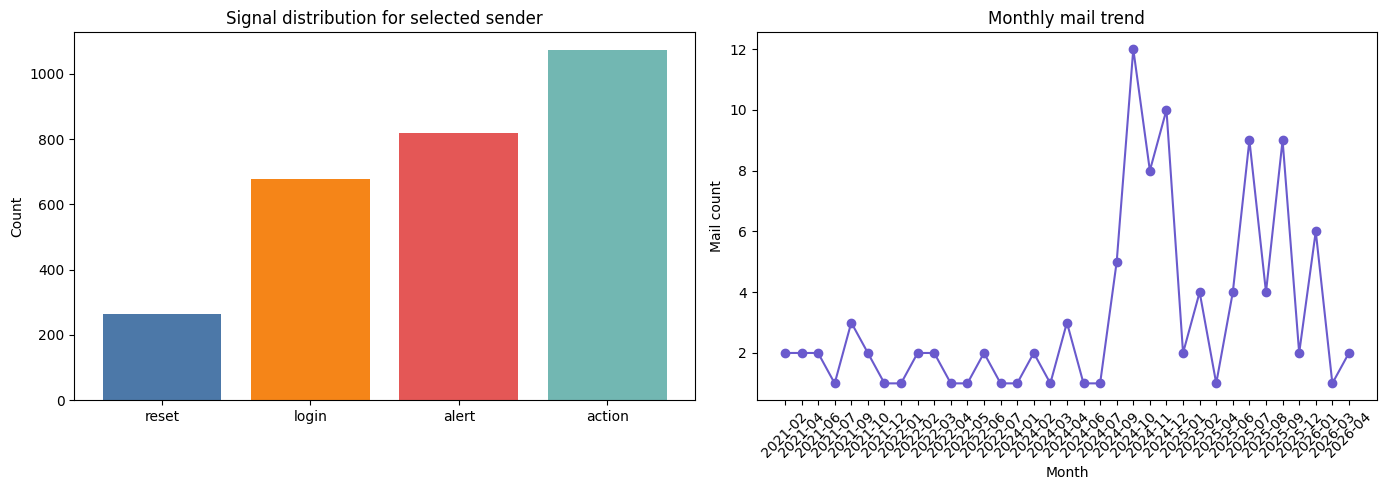

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

if "sender_status_df" not in globals() or sender_status_df.empty:
    raise ValueError("먼저 상태 추정 셀까지 실행해 sender_status_df를 생성하세요.")
if "preprocessed_records" not in globals() or not preprocessed_records:
    raise ValueError("먼저 메일 추출/전처리 셀을 실행하세요.")

# 수동으로 특정 발신자를 보고 싶으면 이메일 주소를 넣으세요.
# None이면 실행할 때마다 랜덤 발신자를 선택합니다.
target_sender = None

report_df_all = pd.DataFrame(preprocessed_records).copy()
report_df_all["sender_key"] = report_df_all["sender_email"].fillna("")
report_df_all["sender_key"] = report_df_all["sender_key"].where(report_df_all["sender_key"] != "", report_df_all["sender"] )

valid_candidates = sender_status_df[sender_status_df["mail_count"] >= 1].copy()
if valid_candidates.empty:
    raise ValueError("리포트를 생성할 발신자가 없습니다.")

selected_sender_key = target_sender
if not selected_sender_key:
    selected_sender_key = valid_candidates["sender_key"].sample(n=1, random_state=None).iloc[0]

sender_report_row = sender_status_df[sender_status_df["sender_key"] == selected_sender_key].iloc[0]

report_df = report_df_all[report_df_all["sender_key"] == selected_sender_key].copy()
report_df["parsed_date"] = pd.to_datetime(report_df["date"], errors="coerce", utc=True)
report_df = report_df.sort_values("parsed_date")

term_counter = {}
if "sender_profiles" in globals() and selected_sender_key in sender_profiles:
    term_counter = sender_profiles[selected_sender_key]

state_reason_map = {
    "복구/비밀번호 재설정": "비밀번호 재설정, 계정 복구, 인증 복원 관련 표현이 반복적으로 나타났습니다.",
    "로그인 이상 탐지": "새 로그인, 인증 코드, 본인 확인, 보안 알림이 함께 관찰되었습니다.",
    "보안 조치 필요": "경고/조치/검토 요청 표현이 누적되어 후속 확인이 필요한 상태입니다.",
    "이상 패턴 감지": "메일 패턴이 다른 발신자에 비해 다르게 나타나 추가 확인이 필요합니다.",
    "로그인/인증 활동": "로그인 및 인증 관련 활동이 중심인 발신자입니다.",
    "일반 보안 알림": "주로 안내성 보안 알림 메일이 관찰됩니다."
}

def score_to_state(score):
    if score >= 5:
        return "위험"
    if score >= 2.5:
        return "주의"
    return "양호"

risk_score_value = float(sender_report_row["risk_score"])
risk_state = score_to_state(risk_score_value)
reason_text = state_reason_map.get(sender_report_row["account_state"], "보안 관련 메일 패턴을 바탕으로 추정했습니다.")

top_subjects = report_df["subject"].value_counts().head(5)
latest_date = report_df["parsed_date"].max()
earliest_date = report_df["parsed_date"].min()

time_series = report_df.dropna(subset=["parsed_date"]).copy()
if not time_series.empty:
    time_series["month"] = time_series["parsed_date"].dt.to_period("M").astype(str)
    monthly_counts = time_series.groupby("month").size().reset_index(name="count")
else:
    monthly_counts = pd.DataFrame(columns=["month", "count"] )

# 최근 6개월 보안 관련 메일 원문 추출
if pd.notna(latest_date):
    cutoff_date = latest_date - pd.DateOffset(months=6)
else:
    cutoff_date = pd.Timestamp.now(tz="UTC") - pd.DateOffset(months=6)

security_terms = ["보안", "security", "로그인", "인증", "비밀번호", "계정", "경고", "차단", "잠금", "의심"]
recent_security_df = report_df.dropna(subset=["parsed_date"]).copy()
recent_security_df = recent_security_df[recent_security_df["parsed_date"] >= cutoff_date].copy()
recent_security_df["combined_text"] = (
    recent_security_df["subject"].fillna("") + "\n" + recent_security_df["body"].fillna("")
).str.lower()
recent_security_df = recent_security_df[
    recent_security_df["combined_text"].apply(lambda x: any(term in x for term in security_terms))
]
recent_security_df = recent_security_df.sort_values("parsed_date", ascending=False)

report_markdown = f"""
## 자동 생성 계정 상태 리포트

### 대상 발신자
- **발신자:** `{sender_report_row['sender_name']}`
- **메일 수:** `{int(sender_report_row['mail_count'])}건`
- **Risk Score:** `{risk_score_value:.2f}`
- **상태(양호/주의/위험):** **{risk_state}**
- **추정 상태(기존 휴리스틱):** **{sender_report_row['account_state']}**
- **이상치 점수:** `{sender_report_row['anomaly_score']:.3f}`
- **대표 토픽:** `{sender_report_row['dominant_topic_name']}`
- **분석 기간:** `{earliest_date}` ~ `{latest_date}`

### 해석
{reason_text}
"""

display(Markdown(report_markdown))

signal_summary = pd.DataFrame({
    "signal": ["reset", "login", "alert", "action"],
    "count": [
        sender_report_row["reset_signal"],
        sender_report_row["login_signal"],
        sender_report_row["alert_signal"],
        sender_report_row["action_signal"],
    ]
})

print("[대표 제목 상위 5개]")
display(top_subjects.rename_axis("subject").reset_index(name="count"))

print("[대표 키워드 상위 15개]")
print(term_counter[:15] if term_counter else "키워드 정보 없음")

print("[최근 메일 10건]")
display(report_df[["parsed_date", "subject", "matched_keywords"]].tail(10))

print("\n[최근 6개월 보안 관련 메일 원문]")
print(f"- 기준일: {cutoff_date}")
print(f"- 건수: {len(recent_security_df)}건")

if recent_security_df.empty:
    print("최근 6개월 내 보안 관련 메일이 없습니다.")
else:
    for idx, row in recent_security_df.iterrows():
        print("\n" + "=" * 80)
        print(f"날짜: {row['parsed_date']}")
        print(f"제목: {row['subject']}")
        print("본문 원문:")
        print(row.get("body", ""))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(signal_summary["signal"], signal_summary["count"], color=["#4c78a8", "#f58518", "#e45756", "#72b7b2"] )
axes[0].set_title("Signal distribution for selected sender")
axes[0].set_ylabel("Count")

if not monthly_counts.empty:
    axes[1].plot(monthly_counts["month"], monthly_counts["count"], marker="o", color="slateblue")
    axes[1].set_title("Monthly mail trend")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Mail count")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].text(0.5, 0.5, "날짜 정보 없음", ha="center", va="center")
    axes[1].set_title("Monthly mail trend")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# 다음 단계에서 재사용
# - selected_sender_key
# - sender_report_row
# - report_df